# Лабораторная работа №2
## Нечёткая база знаний в `skfuzzy`

**Выбранный вариант:** 5 - регулирование теплоснабжения.

Рассматривается нечёткая система, которая определяет мощность теплоснабжения.

Здор Матвей 342951


## 1. Подготовка окружения

Установка библиотек


In [1]:
!python3 -m pip install --upgrade scikit-fuzzy scipy networkx matplotlib numpy pandas


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 10.6 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 1.6 MB/s  0:00:05 eta 0:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.3
    Uninstalling numpy-2.4.3:
      Successfully uninstalled numpy-2.4.3
  Attempting uninstall: pandas━━━━━━━━━━━━━━━━━━ 0/2 [numpy]
    Found existing installation: pandas 3.0.1 0/2 [numpy]
    Uninstalling pandas-3.0.1:0m╺━━━━━━━━━━━━━━━━━━━ 1/2 [pandas]
      Successfully uninstalled pandas-3.0.1━━━━━━━━━━━━━━━━━━━ 1/2 [pandas]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]2m1/2 [pandas]


## 2. Импорт библиотек


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from skfuzzy import control as ctrl


## 3. Лингвистические переменные

В работе используются 3 входные и 1 выходная переменная:

- `temperature` — среднесуточная температура
- `wind` — скорость ветра
- `building_size` — площадь здания
- `heating_power` — мощность теплоснабжения


In [3]:
temperature = ctrl.Antecedent(np.arange(-35, 11, 1), 'temperature')
wind = ctrl.Antecedent(np.arange(0, 21, 1), 'wind')
building_size = ctrl.Antecedent(np.arange(30, 601, 1), 'building_size')
heating_power = ctrl.Consequent(np.arange(0, 101, 1), 'heating_power')


## 4. Функции принадлежности

Для каждой переменной задано по несколько термов.
Для выходной переменной задано 5 термов.


In [4]:
# Температура
temperature['very_cold'] = fuzz.trapmf(temperature.universe, [-35, -35, -25, -15])
temperature['cold'] = fuzz.trimf(temperature.universe, [-22, -12, -2])
temperature['mild'] = fuzz.trapmf(temperature.universe, [-5, 0, 10, 10])

# Ветер
wind['calm'] = fuzz.trapmf(wind.universe, [0, 0, 3, 7])
wind['normal'] = fuzz.trimf(wind.universe, [4, 9, 14])
wind['strong'] = fuzz.trapmf(wind.universe, [10, 14, 20, 20])

# Площадь
building_size['small'] = fuzz.trapmf(building_size.universe, [30, 30, 120, 220])
building_size['medium'] = fuzz.trimf(building_size.universe, [160, 300, 440])
building_size['large'] = fuzz.trapmf(building_size.universe, [380, 480, 600, 600])

# Выход
heating_power['very_low'] = fuzz.trapmf(heating_power.universe, [0, 0, 8, 18])
heating_power['low'] = fuzz.trimf(heating_power.universe, [10, 25, 40])
heating_power['medium'] = fuzz.trimf(heating_power.universe, [30, 50, 70])
heating_power['high'] = fuzz.trimf(heating_power.universe, [60, 75, 90])
heating_power['max'] = fuzz.trapmf(heating_power.universe, [82, 92, 100, 100])


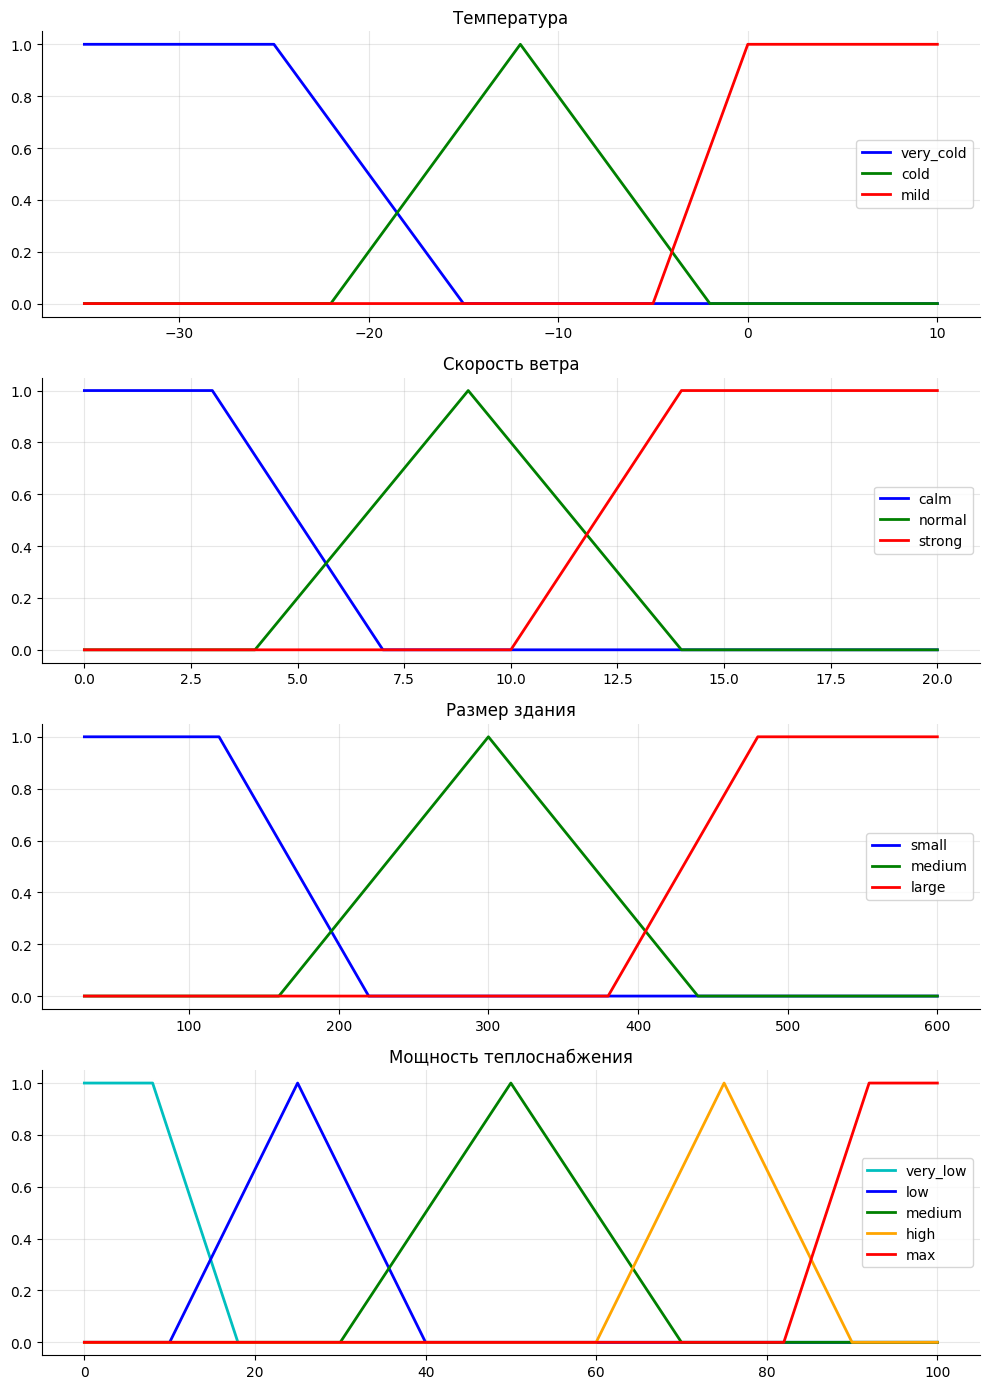

In [5]:
fig, axes = plt.subplots(nrows=4, figsize=(10, 14))

for term_name, style in [('very_cold', 'b'), ('cold', 'g'), ('mild', 'r')]:
    axes[0].plot(temperature.universe, temperature[term_name].mf, style, linewidth=2, label=term_name)
axes[0].set_title('Температура')
axes[0].legend()

for term_name, style in [('calm', 'b'), ('normal', 'g'), ('strong', 'r')]:
    axes[1].plot(wind.universe, wind[term_name].mf, style, linewidth=2, label=term_name)
axes[1].set_title('Скорость ветра')
axes[1].legend()

for term_name, style in [('small', 'b'), ('medium', 'g'), ('large', 'r')]:
    axes[2].plot(building_size.universe, building_size[term_name].mf, style, linewidth=2, label=term_name)
axes[2].set_title('Размер здания')
axes[2].legend()

for term_name, style in [('very_low', 'c'), ('low', 'b'), ('medium', 'g'), ('high', 'orange'), ('max', 'r')]:
    axes[3].plot(heating_power.universe, heating_power[term_name].mf, style, linewidth=2, label=term_name)
axes[3].set_title('Мощность теплоснабжения')
axes[3].legend()

for ax in axes:
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


## 5. Нечёткая база правил

У каждого входа по 3 терма, всего получается 27 комбинаций.
Составлено 27 правил.


In [6]:
rule_map = {
    ('very_cold', 'calm', 'small'): 'high',
    ('very_cold', 'calm', 'medium'): 'high',
    ('very_cold', 'calm', 'large'): 'max',
    ('very_cold', 'normal', 'small'): 'high',
    ('very_cold', 'normal', 'medium'): 'max',
    ('very_cold', 'normal', 'large'): 'max',
    ('very_cold', 'strong', 'small'): 'max',
    ('very_cold', 'strong', 'medium'): 'max',
    ('very_cold', 'strong', 'large'): 'max',

    ('cold', 'calm', 'small'): 'low',
    ('cold', 'calm', 'medium'): 'medium',
    ('cold', 'calm', 'large'): 'high',
    ('cold', 'normal', 'small'): 'medium',
    ('cold', 'normal', 'medium'): 'medium',
    ('cold', 'normal', 'large'): 'high',
    ('cold', 'strong', 'small'): 'high',
    ('cold', 'strong', 'medium'): 'high',
    ('cold', 'strong', 'large'): 'max',

    ('mild', 'calm', 'small'): 'very_low',
    ('mild', 'calm', 'medium'): 'low',
    ('mild', 'calm', 'large'): 'low',
    ('mild', 'normal', 'small'): 'low',
    ('mild', 'normal', 'medium'): 'medium',
    ('mild', 'normal', 'large'): 'medium',
    ('mild', 'strong', 'small'): 'low',
    ('mild', 'strong', 'medium'): 'medium',
    ('mild', 'strong', 'large'): 'high',
}

rules = []
for (temp_term, wind_term, size_term), out_term in rule_map.items():
    rule = ctrl.Rule(
        temperature[temp_term] & wind[wind_term] & building_size[size_term],
        heating_power[out_term],
        label=f'IF {temp_term} AND {wind_term} AND {size_term} THEN {out_term}'
    )
    rules.append(rule)

print(f'Количество правил: {len(rules)}')


Количество правил: 27


In [7]:
for index, ((temp_term, wind_term, size_term), out_term) in enumerate(rule_map.items(), start=1):
    print(f'{index:02d}. ЕСЛИ temperature = {temp_term}, wind = {wind_term}, building_size = {size_term}, ТО heating_power = {out_term}')


01. ЕСЛИ temperature = very_cold, wind = calm, building_size = small, ТО heating_power = high
02. ЕСЛИ temperature = very_cold, wind = calm, building_size = medium, ТО heating_power = high
03. ЕСЛИ temperature = very_cold, wind = calm, building_size = large, ТО heating_power = max
04. ЕСЛИ temperature = very_cold, wind = normal, building_size = small, ТО heating_power = high
05. ЕСЛИ temperature = very_cold, wind = normal, building_size = medium, ТО heating_power = max
06. ЕСЛИ temperature = very_cold, wind = normal, building_size = large, ТО heating_power = max
07. ЕСЛИ temperature = very_cold, wind = strong, building_size = small, ТО heating_power = max
08. ЕСЛИ temperature = very_cold, wind = strong, building_size = medium, ТО heating_power = max
09. ЕСЛИ temperature = very_cold, wind = strong, building_size = large, ТО heating_power = max
10. ЕСЛИ temperature = cold, wind = calm, building_size = small, ТО heating_power = low
11. ЕСЛИ temperature = cold, wind = calm, building_size =

## 6. Вывод для конкретных значений

Пример для входных данных:

- температура: **-17 °C**;
- ветер: **12 м/с**;
- площадь здания: **380 м²**.


In [8]:
heating_ctrl = ctrl.ControlSystem(rules)
heating_simulator = ctrl.ControlSystemSimulation(heating_ctrl)

heating_simulator.input['temperature'] = -17
heating_simulator.input['wind'] = 12
heating_simulator.input['building_size'] = 380

heating_simulator.compute()

print(f"Рекомендуемая мощность теплоснабжения: {heating_simulator.output['heating_power']:.2f}%")


Рекомендуемая мощность теплоснабжения: 64.01%


/Users/matveyzdor/Library/Python/3.14/lib/python/site-packages/skfuzzy/control/fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


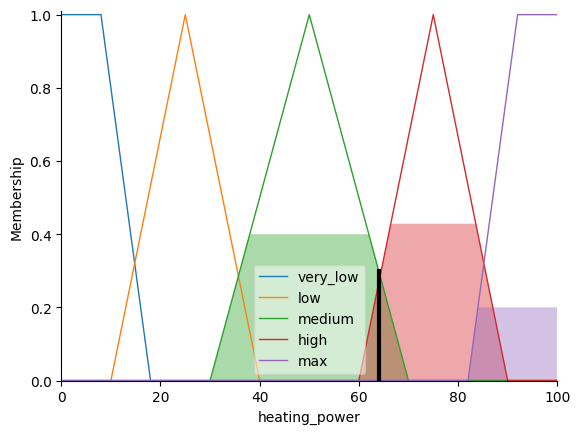

In [9]:
heating_power.view(sim=heating_simulator)
plt.show()


## 7. Случайные прогоны

Проведём 5 случайных прогонов.


In [10]:
rng = np.random.default_rng(42)
random_runs = []

for run_id in range(1, 6):
    current_sim = ctrl.ControlSystemSimulation(heating_ctrl)

    temp_value = float(rng.uniform(-30, 8))
    wind_value = float(rng.uniform(0, 16))
    size_value = float(rng.uniform(50, 550))

    current_sim.input['temperature'] = temp_value
    current_sim.input['wind'] = wind_value
    current_sim.input['building_size'] = size_value
    current_sim.compute()

    random_runs.append({
        'run': run_id,
        'temperature': round(temp_value, 2),
        'wind': round(wind_value, 2),
        'building_size': round(size_value, 1),
        'heating_power': round(float(current_sim.output['heating_power']), 2)
    })

for item in random_runs:
    print(item)


{'run': 1, 'temperature': -0.59, 'wind': 7.02, 'building_size': 479.3, 'heating_power': 50.0}
{'run': 2, 'temperature': -3.5, 'wind': 1.51, 'building_size': 537.8, 'heating_power': 42.62}
{'run': 3, 'temperature': -1.08, 'wind': 12.58, 'building_size': 114.1, 'heating_power': 25.0}
{'run': 4, 'temperature': -12.89, 'wind': 5.93, 'building_size': 513.4, 'heating_power': 75.0}
{'run': 5, 'temperature': -5.53, 'wind': 13.16, 'building_size': 271.7, 'heating_power': 64.67}


In [11]:
try:
    import pandas as pd
    display(pd.DataFrame(random_runs))
except ImportError:
    print('Pandas не установлен, поэтому показываем результаты как список словарей выше.')


,run,temperature,wind,building_size,heating_power
0,1,-0.59,7.02,479.3,50.00
1,2,-3.50,1.51,537.8,42.62
2,3,-1.08,12.58,114.1,25.00
3,4,-12.89,5.93,513.4,75.00
4,5,-5.53,13.16,271.7,64.67
